## 环形蜂窝条形图将两个图形相结合，既保留了蜂窝图展示个体样本细节的能力，又兼具条形图反映对预测影响的大小。

读取文件出错: [Errno 2] No such file or directory: 'F:\\data.xlsx'


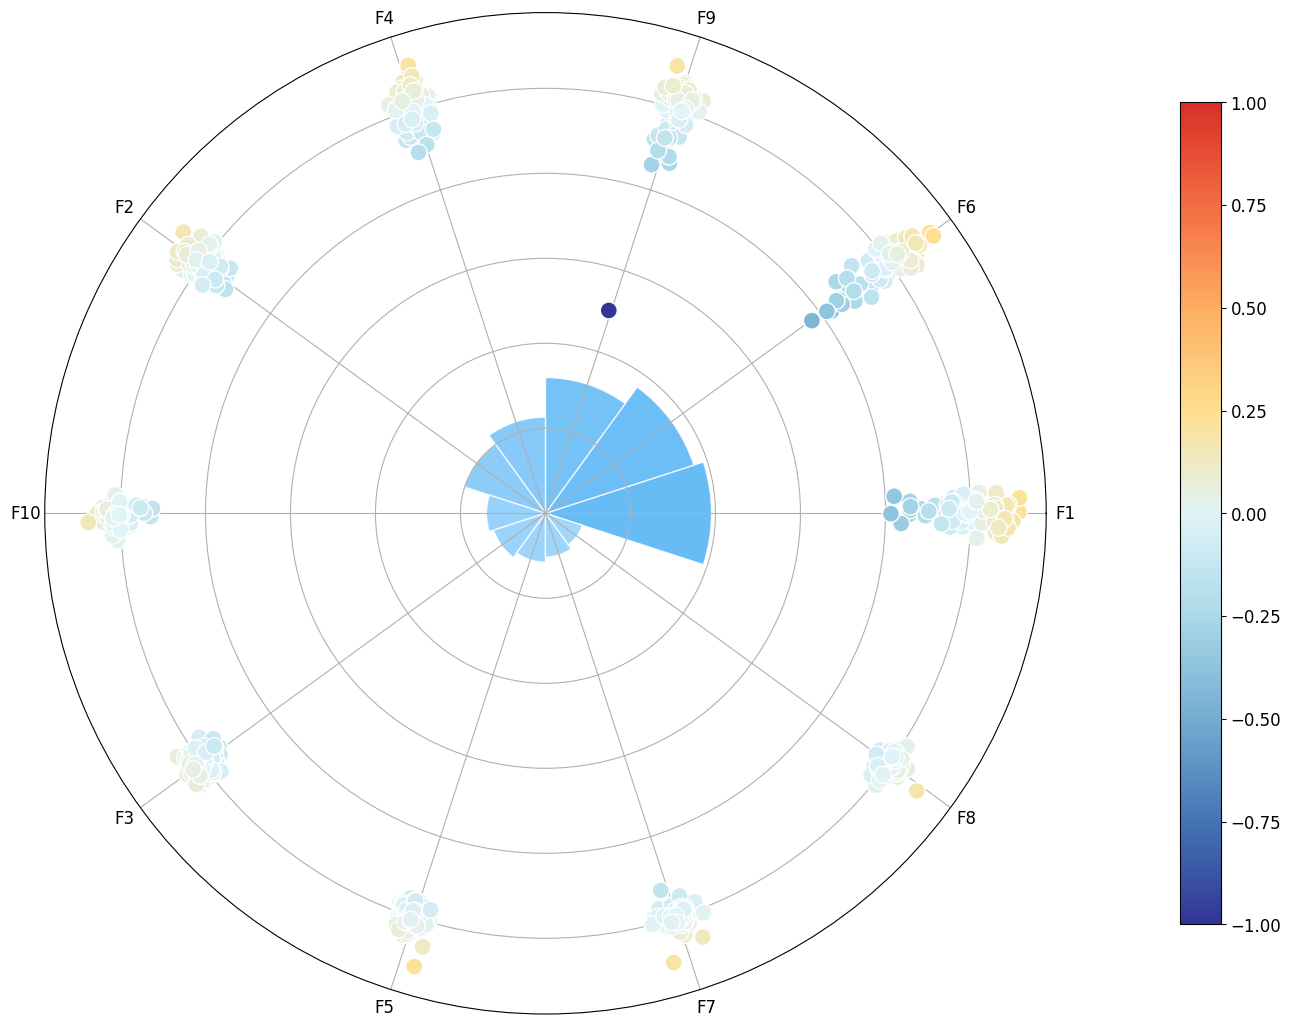

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
# ================ 数据准备阶段 ================
try:
    # 尝试读取 Excel 数据
    data = pd.read_excel(r'F:\data.xlsx', engine='openpyxl', sheet_name='Sheet1')
except Exception as e:
    print(f"读取文件出错: {e}")
    # 如果读取失败，创建模拟数据（用于演示）
    np.random.seed(42)  # 固定随机种子保证可重复性
    n_samples = 100
    data = pd.DataFrame({
        # 生成10个正态分布的特征列
        'F1': np.random.normal(5, 1, n_samples),
        'F2': np.random.normal(0, 0.5, n_samples),
        'F3': np.random.normal(10, 2, n_samples),
        'F4': np.random.normal(20, 5, n_samples),
        'F5': np.random.normal(25, 3, n_samples),
        'F6': np.random.normal(0.1, 0.05, n_samples),
        'F7': np.random.normal(7, 0.5, n_samples),
        'F8': np.random.normal(-2, 0.5, n_samples),
        'F9': np.random.normal(3, 1, n_samples),
        'F10': np.random.normal(-1, 0.3, n_samples),
        # 目标变量
        'F11': np.random.normal(2, 1, n_samples)
    })

# 设置列名（如果 Excel 没有列名）
data.columns = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11']
target = "F11"  # 指定目标变量

# 条形图高度放大系数（调整内部条形图的显著程度）
magnification_factor = 3

# ================ 配色方案设置 ================
# 内部条形图颜色（渐变从浅到深）
bar_colors = ["#a0d7fd", "#42abf4"]  # 示例蓝系渐变，可按需调整
# 定义从蓝到红渐变的颜色（使用16进制颜色代码）
custom_color = ["#313695", "#4575b4", "#74add1", "#abd9e9",  # 蓝色系
                "#e0f3f8",  # 中性白色
                "#fee090", "#fdae61", "#f46d43", "#d73027"]  # 红色系

# ================ 假设你已通过模型得到 shap_values（这里需结合实际模型训练，如 XGBoost、LightGBM 等） ================
# 以下为演示占位，实际需替换为真实 SHAP 值计算结果
import shap
from sklearn.ensemble import RandomForestRegressor  # 以随机森林为例，可换其他模型

# 拟合模型（示例，用模拟数据训练）
X = data.drop(columns=target)
y = data[target]
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# 计算 SHAP 值
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
feats = X.columns.tolist()

# ================ 1. 绘制径向条形图（背景层） ================
# 计算特征重要性（平均绝对 SHAP 值）
feature_importance = {}
for i, feature in enumerate(feats):
    feature_importance[feature] = np.abs(shap_values[:, i]).mean()

# 按重要性降序排序
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
sorted_feature_names = [x[0] for x in sorted_features]  # 排序后的特征名
sorted_importance_values = [x[1] for x in sorted_features]  # 排序后的重要性值

# 计算每个条形在极坐标中的角度
num_features = len(sorted_feature_names)
width = 2 * np.pi / num_features  # 条形宽度
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False)  # 均分360度

# 归一化重要性值（0 - 1 范围）
max_importance = max(sorted_importance_values)
normalized_importance = [val / max_importance for val in sorted_importance_values]

# 创建条形图颜色映射（使用自定义蓝绿渐变）
bar_cmap = LinearSegmentedColormap.from_list("bar_colors", bar_colors)
norm = Normalize(vmin=0, vmax=1)
importance_colors = bar_cmap(norm(normalized_importance))  # 根据归一化值获取颜色

# 创建极坐标画布
plt.figure(figsize=(14, 14))  # 大画布保证清晰度
ax = plt.subplot(111, projection='polar')  # 极坐标投影

# 绘制径向条形图（使用放大后的高度）
bars = ax.bar(
    angles,
    np.array(sorted_importance_values) * magnification_factor,  # 放大高度
    width=width,
    bottom=0.0,
    alpha=0.8,  # 透明度
    color=importance_colors,
    edgecolor='white',  # 条形边框
    linewidth=1,
    zorder=1  # 图层顺序（底层）
)

# ================ 2. 蜂窝图绘制 ================
# SHAP 值预处理
# 按排序后的特征顺序存储 SHAP 值
feature_shap_values = {}
for i, feature in enumerate(sorted_feature_names):
    feature_shap_values[feature] = shap_values[:, feats.index(feature)]

# 归一化 SHAP 值到 [-1, 1] 范围
max_abs_shap = np.max([np.abs(vals).max() for vals in feature_shap_values.values()])
normalized_feature_shap_values = {
    feature: vals / max_abs_shap if max_abs_shap > 0 else vals
    for feature, vals in feature_shap_values.items()
}

# 创建自定义颜色映射（蓝绿渐变 结合 红系，按需调整）
cmap = LinearSegmentedColormap.from_list("custom_color", custom_color)
# 标准化器（将值映射到 -1 到 1 对应颜色）
shap_norm = Normalize(vmin=-1, vmax=1)
sm = ScalarMappable(cmap=cmap, norm=shap_norm)

# 为每个特征绘制散点
for i, feature in enumerate(sorted_feature_names):
    # 获取当前特征的归一化 SHAP 值
    normalized_shap_vals = normalized_feature_shap_values[feature]

    # 计算散点半径（1 为基准圆，±0.5 范围内波动 ，可按需调）
    radii = 1 + normalized_shap_vals / 2  

    # 添加随机角度偏移（避免点重叠）
    angle_jitter = np.random.normal(0, 0.02, len(normalized_shap_vals))
    point_angles = angles[i] + angle_jitter  # 在特征角度附近随机分布

    # 绘制散点（颜色反映 SHAP 值大小和方向）
    sc = ax.scatter(
        point_angles,
        radii,
        c=normalized_shap_vals,  # 颜色值
        cmap=cmap,
        s=150,  # 点大小
        alpha=1,  # 不透明
        edgecolors='white',  # 白色边框
        linewidths=1,
        norm=shap_norm,  # 标准化
        zorder=3  # 顶层，盖在条形图上
    )

# ================ 3. 设置极坐标轴格式和标签 ================
# 颜色条设置
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, orientation='vertical', pad=0.1)
cbar.ax.tick_params(labelsize=12)  # 刻度字号
# cbar.set_label('归一化 SHAP 值', fontsize=14)  # 标签字号

# 标题和输出
# plt.title('特征 SHAP 值蜂窝图与重要性条形图', fontsize=20, pad=24)
ax.set_xticks(angles)
ax.set_xticklabels(sorted_feature_names, fontsize=12)  # 设置特征名标签
ax.set_yticklabels([])  # 隐藏径向刻度标签（按需显示）

plt.tight_layout()  # 自动调整布局
plt.show()